In [1]:
from pathlib import Path
import sys
import os
import numpy as np


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive") # mount the drive
    DATA_PATH = Path("/content/drive/MyDrive") # the root of the drive
    DATA_ROOT = DATA_PATH / "cbc_pe_data" # the root of the data
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    DATA_ROOT = PROJECT_ROOT / "data"


DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" # the root of the checkpoints

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)



#Clone the repository if it doesn't exist
if IN_COLAB:
    REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
    PROJECT_ROOT = REPO_ROOT / "cbc_pe"

    if not REPO_ROOT.exists():
        !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

    print("REPO_ROOT exists:", REPO_ROOT.exists())
    print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

    #Pull the latest version of the repository
    %cd /content/Gravitational-Waves-Lab
    !git pull
    !git status

    #Go to the project root
    %cd /content/Gravitational-Waves-Lab/cbc_pe
else:
    %cd /home/victor/gw/cbc_pe
    


# Add the project root to the python path
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

DATA_ROOT: /home/victor/gw/cbc_pe/data
DATA_RAW: /home/victor/gw/cbc_pe/data/raw
MODELS_DIR: /home/victor/gw/cbc_pe/data/models
RESULTS_DIR: /home/victor/gw/cbc_pe/data/results
CHECKPOINTS_DIR: /home/victor/gw/cbc_pe/data/models/checkpoints
/home/victor/gw/cbc_pe
cwd: /home/victor/gw/cbc_pe
sys.path[:3]: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12']


In [2]:
from pathlib import Path
import numpy as np

from src.io import load_dataset_npz

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500"

dataset_path = DATA_PROCESSED / f"{dataset_id}.npz"
split_path = DATA_PROCESSED / f"{dataset_id}_splits.npz"

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
metadata = batch.metadata
network_snrs = np.array([ m["snr"]["final_network_snr"] for m in metadata], dtype=np.float32)
label_names = ["chirp_mass", "total_mass", "chi_eff"]


splits = np.load(split_path)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
cal_idx = splits["cal_idx"]
test_idx = splits["test_idx"]

X_train, y_train_phys = X[train_idx], y[train_idx]
X_val, y_val_phys = X[val_idx], y[val_idx]
X_cal, y_cal_phys = X[cal_idx], y[cal_idx]
X_test, y_test_phys = X[test_idx], y[test_idx]

In [3]:
label_stats_path = DATA_PROCESSED / f"{dataset_id}_label_stats_train_only.npz"

y_params = np.load(label_stats_path)
y_mean = y_params["mean"]
y_std = y_params["std"]

y_train_std = (y_train_phys - y_mean) / y_std
y_val_std = (y_val_phys - y_mean) / y_std
y_cal_std = (y_cal_phys - y_mean) / y_std
y_test_std = (y_test_phys - y_mean) / y_std

## Datasets and Dataloaders

In [4]:
from torch.utils.data import DataLoader
from src.models.dataset import ArrayRegressionDataset

batch_size = 32

train_dataset = ArrayRegressionDataset(X_train, y_train_std)
val_dataset = ArrayRegressionDataset(X_val, y_val_std)
cal_dataset = ArrayRegressionDataset(X_cal, y_cal_std)
test_dataset = ArrayRegressionDataset(X_test, y_test_std)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

cal_loader = DataLoader(
    cal_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,

)

## Load the checkpoint

In [5]:
import torch
from src.models.network import SimpleCNN


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_file_name = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500_checkpoint.pt"

checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model_config = checkpoint["model_config"]

In [6]:
import torch
from src.models.network import SimpleCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_file_name = "bbh_processed_4s_seobnrv4opt_snr10-25_n4500_checkpoint.pt"
checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(checkpoint_path, map_location=device)

model_config = checkpoint["model_config"]

model = SimpleCNN(
    n_detectors=model_config["n_detectors"],
    n_outputs=model_config["n_outputs"],
    embedding_dim=model_config["embedding_dim"],
    dropout_conv=model_config["dropout_conv"],
    dropout_dense=model_config["dropout_dense"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Loaded best val loss:", checkpoint["best_val_loss"])

Loaded epoch: 98
Loaded best val loss: 0.513808821439743


This function uses the model for the prediction inference

In [7]:
def predict_set(model, dataloader, device):
    model.eval()
    pred = []
    true = []
    emb = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)

            pred_batch, emb_batch = model(X_batch, return_embedding=True)

            pred.append(pred_batch.cpu().numpy())
            true.append(y_batch.numpy())
            emb.append(emb_batch.cpu().numpy())
            
    return np.concatenate(pred, axis=0), np.concatenate(true, axis=0), np.concatenate(emb, axis=0)

In [8]:
#Standardized predictions (y_std where used in the dataloader)
pred_train, y_train, emb_train = predict_set(model, train_loader, device)
pred_val, y_val, emb_val = predict_set(model, val_loader, device)
pred_cal, y_cal, emb_cal = predict_set(model, cal_loader, device)
pred_test, y_test, emb_test = predict_set(model, test_loader, device)



In [9]:
def mse(pred, y):
    if len(y)!=len(pred):
        raise ("y and pred must have the same length")
    
    return (np.sum( (pred - y)**2, axis=0 ) / len(y))


def mae(pred, y):
    if len(y)!=len(pred):
        raise ("y and pred must have the same length")
    
    return (np.sum( np.abs(pred - y), axis=0 ) / len(y))


def bias(pred, y):
    if len(y)!=len(pred):
        raise ("y and pred must have the same length")
    
    return (np.sum( (pred - y), axis=0 ) / len(y))


def median_mae(pred, y):
    if len(y)!=len(pred):
        raise ("y and pred must have the same length")
    
    return np.median( np.abs(pred - y), axis=0)


def R2(pred, y):
    """
    El coeficiente R2 mide qué fracción de la varianza del target explica el modelo.
        - R² = 1 -> predicción perfecta
        - R² = 0 -> igual que predecir siempre la media del target
        - R² < 0 -> peor que predecir siempre la media
    """
    if len(y)!=len(pred):
        raise ("y and pred must have the same length")
    
    ss_res = np.sum((y - pred) ** 2, axis=0)
    ss_tot = np.sum((y - np.mean(y, axis=0)) ** 2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    return r2


In [10]:
mse_train = mse(pred_train, y_train)
mse_val = mse(pred_val, y_val)

rmse_train = np.sqrt(mse_train)

mae_train = mae(pred_train, y_train)

bias_train = bias(pred_train, y_train)

median_mae_train = median_mae(pred_train, y_train)

r2_train = R2(pred_train, y_train)

residual_std_train = pred_train - y_train
residual_std_val = pred_val - y_val
residual_std_cal = pred_cal - y_cal
residual_std_test = pred_test - y_test

abs_residual_std_train = np.abs(residual_std_train)
abs_residual_std_val = np.abs(residual_std_val)
abs_residual_std_cal = np.abs(residual_std_cal)
abs_residual_std_test = np.abs(residual_std_test)

print(mse_train)
print(rmse_train)
print(mae_train)
print(bias_train)
print(median_mae_train)
print(r2_train)

[0.3043512  0.27968997 0.82962555]
[0.5516803  0.52885723 0.9108378 ]
[0.42450544 0.42935166 0.753663  ]
[-0.01759012 -0.02390768  0.04208083]
[0.33599374 0.3744275  0.6878163 ]
[0.69564867 0.72031033 0.17037362]


In [11]:
import pandas as pd
from src.models.evaluate import regression_metrics

metrics_train_std = regression_metrics(y_train, pred_train, label_names, "train_std")
metrics_val_std   = regression_metrics(y_val, pred_val, label_names, "val_std")
metrics_cal_std   = regression_metrics(y_cal, pred_cal, label_names, "cal_std")
metrics_test_std  = regression_metrics(y_test, pred_test, label_names, "test_std")

metrics_all_std = pd.concat(
    [metrics_train_std, metrics_val_std, metrics_cal_std, metrics_test_std],
    ignore_index=True
)

metrics_all_std

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,train_std,chirp_mass,0.304351,0.551680,0.424505,-0.017590,0.335994,0.551400,0.695649
1,train_std,total_mass,0.279690,0.528857,0.429352,-0.023908,0.374427,0.528317,0.720310
2,train_std,chi_eff,0.829626,0.910838,0.753663,0.042081,0.687816,0.909865,0.170374
3,val_std,chirp_mass,0.399915,0.632388,0.487841,0.021096,0.412779,0.632036,0.604640
4,val_std,total_mass,0.359044,0.599203,0.491985,0.021495,0.452442,0.598817,0.645373
5,val_std,chi_eff,0.782475,0.884576,0.723401,0.090528,0.608727,0.879932,0.187679
6,cal_std,chirp_mass,0.424035,0.651180,0.497138,0.010025,0.376175,0.651103,0.591316
7,cal_std,total_mass,0.386481,0.621676,0.502568,-0.017977,0.429164,0.621415,0.626734
8,cal_std,chi_eff,0.875700,0.935788,0.772090,0.124708,0.703318,0.927442,0.159039
9,test_std,chirp_mass,0.486037,0.697164,0.531754,0.014193,0.415088,0.697019,0.528749


In physical space

In [12]:
y_test_phys = y_test * y_std + y_mean
pred_test_phys = pred_test * y_std + y_mean

In [13]:
metrics_test_phys = regression_metrics(
    y_true=y_test_phys,
    y_pred=pred_test_phys,
    label_names=label_names,
    split_name="test_phys"
)

metrics_test_phys

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,test_phys,chirp_mass,129.436264,11.377006,8.677685,0.231608,6.773811,11.374648,0.528749
1,test_phys,total_mass,480.949768,21.930567,17.588614,0.474859,14.879982,21.925423,0.589690
2,test_phys,chi_eff,0.156082,0.395072,0.327470,0.039572,0.300856,0.393085,0.207368


## 1. Compute some metrics

In [14]:
from src.models.evaluate import inverse_standardize

pred_train_phys = inverse_standardize(pred_train, y_mean, y_std)
pred_val_phys   = inverse_standardize(pred_val,   y_mean, y_std)
pred_cal_phys   = inverse_standardize(pred_cal,   y_mean, y_std)
pred_test_phys  = inverse_standardize(pred_test,  y_mean, y_std)

y_train_phys = inverse_standardize(y_train, y_mean, y_std)
y_val_phys   = inverse_standardize(y_val,   y_mean, y_std)
y_cal_phys   = inverse_standardize(y_cal,   y_mean, y_std)
y_test_phys  = inverse_standardize(y_test,  y_mean, y_std)

In [15]:
metrics_train_phys = regression_metrics(y_train_phys, pred_train_phys, label_names, "train_phys")
metrics_val_phys   = regression_metrics(y_val_phys,   pred_val_phys,   label_names, "val_phys")
metrics_cal_phys   = regression_metrics(y_cal_phys,   pred_cal_phys,   label_names, "cal_phys")
metrics_test_phys  = regression_metrics(y_test_phys,  pred_test_phys,  label_names, "test_phys")

metrics_all_phys = pd.concat(
    [metrics_train_phys, metrics_val_phys, metrics_cal_phys, metrics_test_phys],
    ignore_index=True
)

metrics_all_phys

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,train_phys,chirp_mass,81.051651,9.002869,6.927497,-0.287053,5.483078,8.998289,0.695648
1,train_phys,total_mass,324.424500,18.011787,14.622801,-0.814245,12.752216,17.993372,0.720309
2,train_phys,chi_eff,0.159360,0.399199,0.330314,0.018443,0.301454,0.398773,0.170375
3,val_phys,chirp_mass,106.501144,10.319940,7.961065,0.344273,6.736130,10.314192,0.604640
4,val_phys,total_mass,416.470367,20.407606,16.755978,0.732072,15.409237,20.394474,0.645373
5,val_phys,chi_eff,0.150303,0.387689,0.317050,0.039676,0.266791,0.385654,0.187679
6,cal_phys,chirp_mass,112.924576,10.626597,8.112780,0.163601,6.138799,10.625338,0.591316
7,cal_phys,total_mass,448.294617,21.172970,17.116392,-0.612267,14.616442,21.164112,0.626735
8,cal_phys,chi_eff,0.168211,0.410135,0.338389,0.054657,0.308248,0.406477,0.159038
9,test_phys,chirp_mass,129.436264,11.377006,8.677685,0.231608,6.773811,11.374648,0.528749


## 2. Plot pred vs true

Qué mirar:

- Si los puntos siguen la diagonal.
- Si hay saturación en masas altas.
- Si hay regresión a la media.
- Si chi_eff está comprimido cerca de cero.

Mi predicción: chi_eff tendrá bastante regresión a la media.

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_true(y_true, y_pred, label_names, split_name="test"):
    for j, label in enumerate(label_names):
        true = y_true[:, j]
        pred = y_pred[:, j]

        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())

        plt.figure(figsize=(8, 8))
        plt.scatter(true, pred, s=12, alpha=0.6)
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
        plt.xlabel(f"True {label}")
        plt.ylabel(f"Predicted {label}")
        plt.title(f"{split_name}: predicted vs true — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

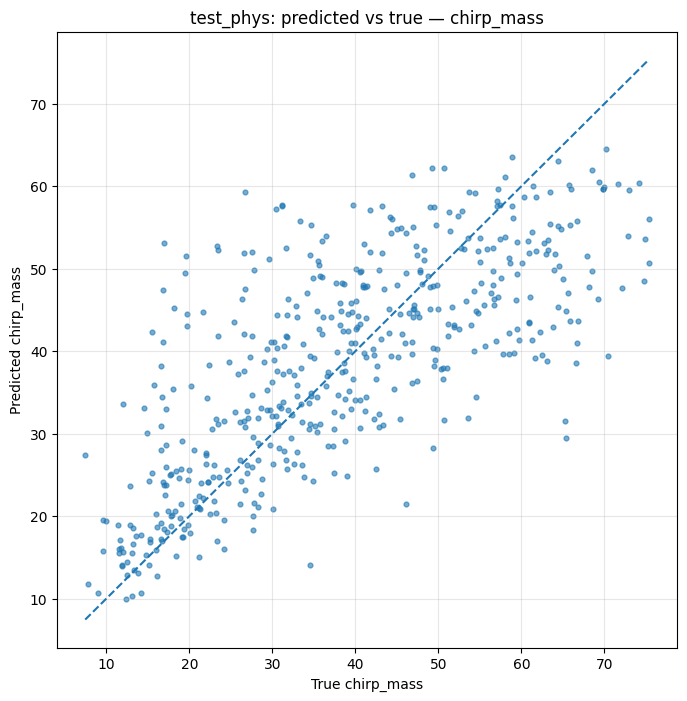

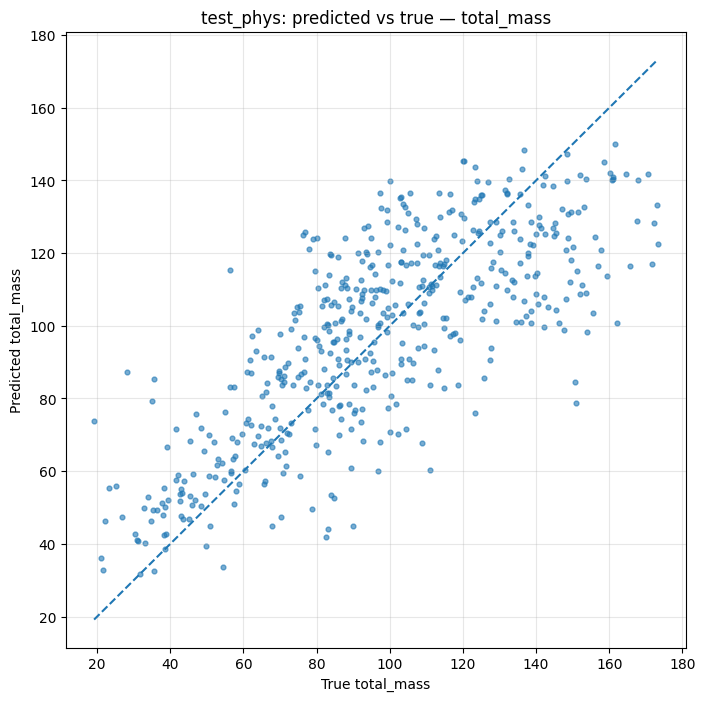

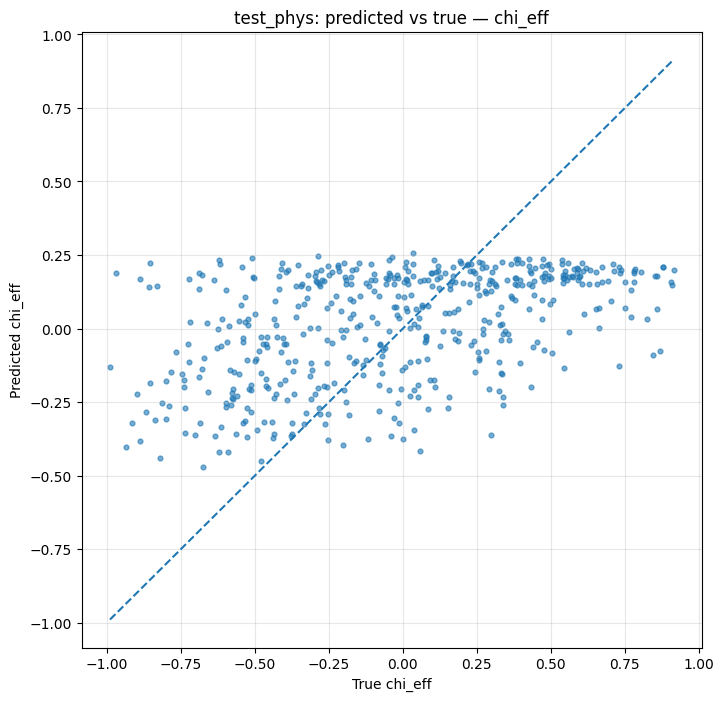

In [17]:
plot_pred_vs_true(
    y_true=y_test_phys,
    y_pred=pred_test_phys,
    label_names=label_names,
    split_name="test_phys"
)

## 3. Residuals per label

In [18]:
def plot_residuals(y_true, y_pred, label_names, split_name="test"):
    residual = y_pred - y_true

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.hist(residual[:, j], bins=40, alpha=0.8)
        plt.axvline(0.0, linestyle="--")
        plt.xlabel(f"Residual: pred - true ({label})")
        plt.ylabel("Count")
        plt.title(f"{split_name}: residual distribution — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

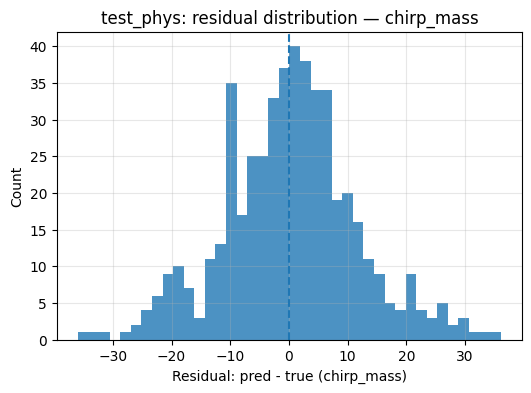

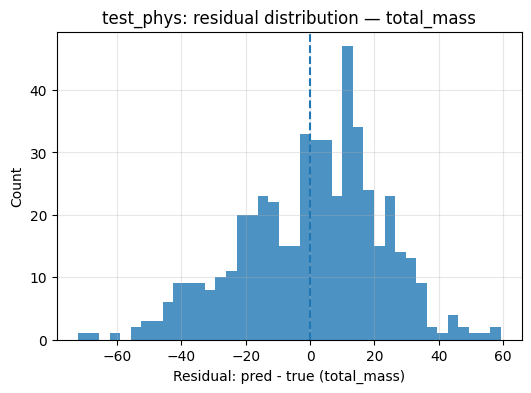

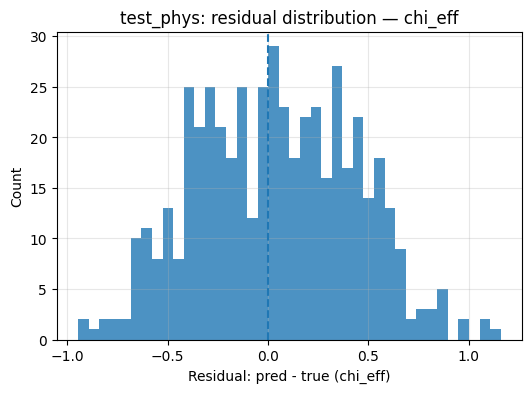

In [19]:
plot_residuals(y_test_phys, pred_test_phys, label_names, "test_phys")

In [20]:
def plot_residual_vs_true(y_true, y_pred, label_names, split_name="test"):
    residual = y_pred - y_true

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(y_true[:, j], residual[:, j], s=12, alpha=0.6)
        plt.axhline(0.0, linestyle="--")
        plt.xlabel(f"True {label}")
        plt.ylabel(f"Residual: pred - true")
        plt.title(f"{split_name}: residual vs true — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

Esto es más importante que el histograma. Te dirá dónde falla el modelo.

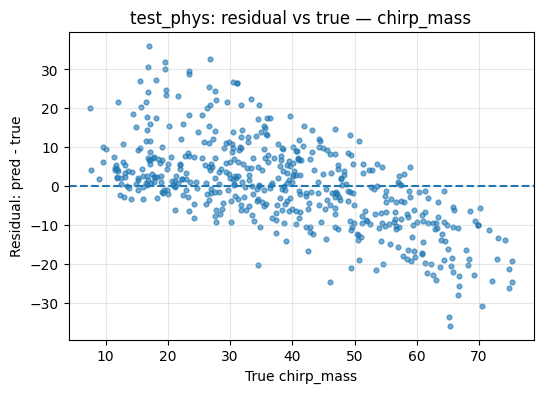

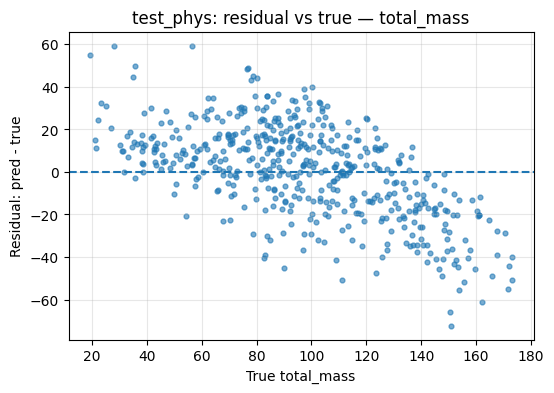

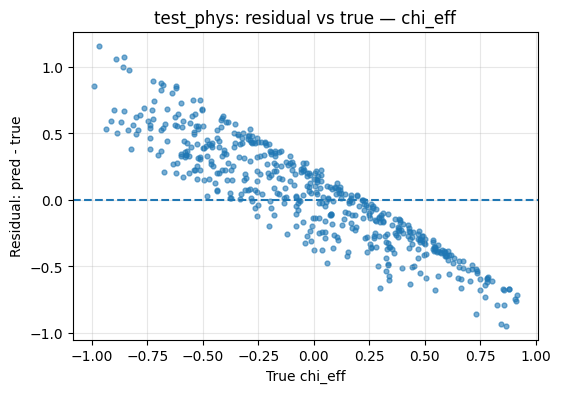

In [21]:
plot_residual_vs_true(y_test_phys, pred_test_phys, label_names, "test_phys")

## 4. Absolute error vs true value

Este plot es clave para Mondrian. Si el error aumenta con masa o depende de chi_eff, entonces tiene sentido usar bins condicionados.

In [22]:
def plot_abs_error_vs_true(y_true, y_pred, label_names, split_name="test"):
    abs_error = np.abs(y_pred - y_true)

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(y_true[:, j], abs_error[:, j], s=12, alpha=0.6)
        plt.xlabel(f"True {label}")
        plt.ylabel(f"Absolute error")
        plt.title(f"{split_name}: absolute error vs true — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

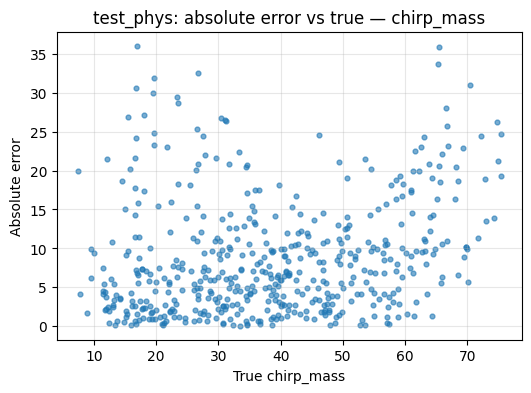

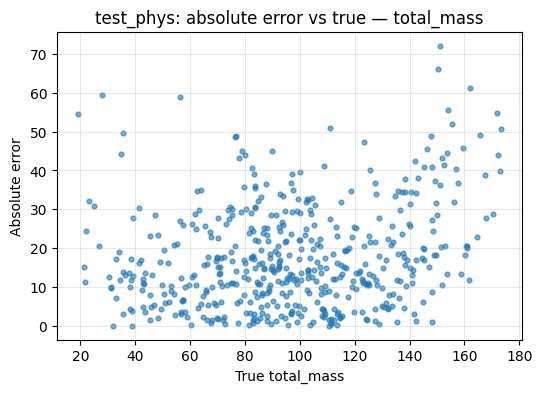

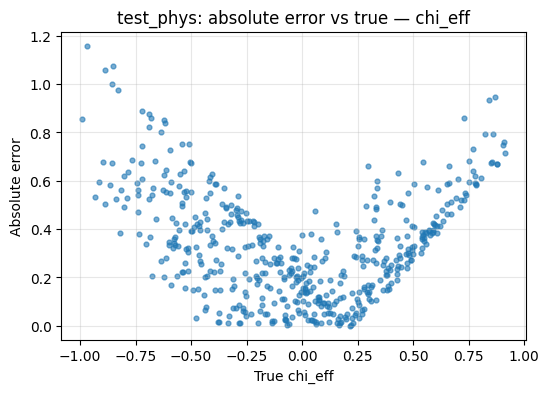

In [23]:
plot_abs_error_vs_true(y_test_phys, pred_test_phys, label_names, "test_phys")

## 5. Error vs SNR

In [24]:
snr_test = network_snrs[test_idx]

In [25]:
def plot_abs_error_vs_quantity(quantity, y_true, y_pred, label_names, quantity_name, split_name="test"):
    abs_error = np.abs(y_pred - y_true)

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(quantity, abs_error[:, j], s=12, alpha=0.6)
        plt.xlabel(quantity_name)
        plt.ylabel(f"Absolute error in {label}")
        plt.title(f"{split_name}: abs error vs {quantity_name} — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

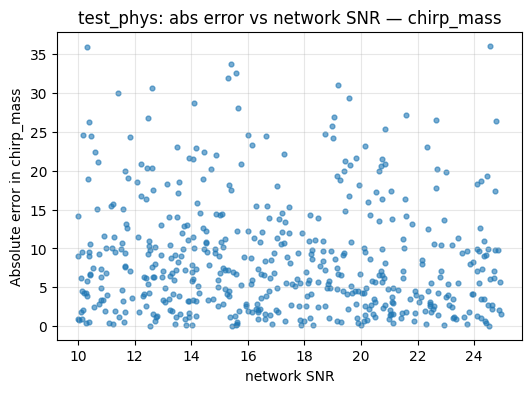

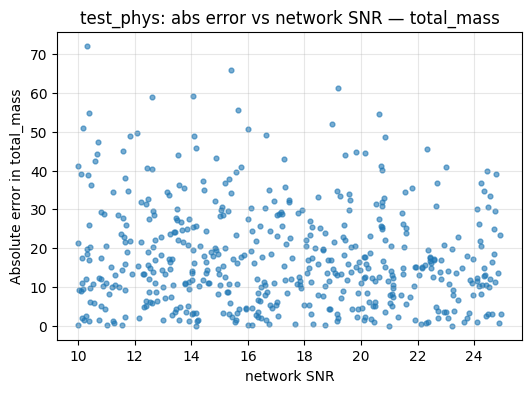

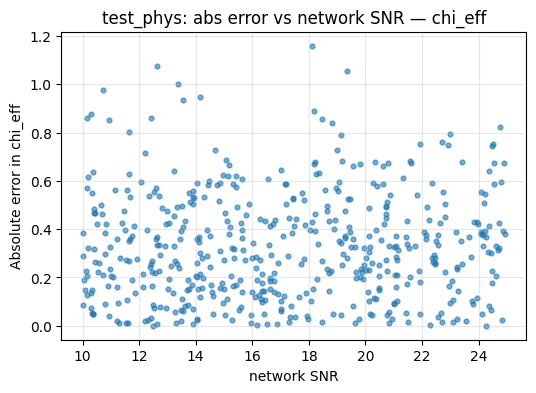

In [26]:
plot_abs_error_vs_quantity(
    quantity=snr_test,
    y_true=y_test_phys,
    y_pred=pred_test_phys,
    label_names=label_names,
    quantity_name="network SNR",
    split_name="test_phys"
)

For bins

In [27]:
def metrics_by_quantity_bins(quantity, y_true, y_pred, label_names, bin_edges, quantity_name):
    rows = []

    for b in range(len(bin_edges) - 1):
        lo = bin_edges[b]
        hi = bin_edges[b + 1]

        mask = (quantity >= lo) & (quantity < hi)

        if mask.sum() == 0:
            continue

        residual = y_pred[mask] - y_true[mask]
        abs_error = np.abs(residual)

        for j, label in enumerate(label_names):
            rows.append({
                "quantity": quantity_name,
                "bin": f"[{lo:.2f}, {hi:.2f})",
                "count": int(mask.sum()),
                "label": label,
                "MAE": abs_error[:, j].mean(),
                "RMSE": np.sqrt((residual[:, j] ** 2).mean()),
                "bias": residual[:, j].mean(),
                "median_abs_error": np.median(abs_error[:, j]),
            })

    return pd.DataFrame(rows)

In [31]:


snr_edges = np.linspace(10, 25, 7)

metrics_snr_test = metrics_by_quantity_bins(
    quantity=snr_test,
    y_true=y_test_phys,
    y_pred=pred_test_phys,
    label_names=label_names,
    bin_edges=snr_edges,
    quantity_name="network_snr"
)


snr_by_label = metrics_snr_test.sort_values(by="label", kind="stable")


display(snr_by_label)

,quantity,bin,count,label,MAE,RMSE,bias,median_abs_error
2,network_snr,"[10.00, 12.50)",85,chi_eff,0.325310,0.398707,0.082838,0.271867
5,network_snr,"[12.50, 15.00)",98,chi_eff,0.321106,0.395221,0.049286,0.283370
8,network_snr,"[15.00, 17.50)",89,chi_eff,0.283962,0.341822,-0.016624,0.271528
11,network_snr,"[17.50, 20.00)",76,chi_eff,0.388458,0.460495,0.035825,0.361140
14,network_snr,"[20.00, 22.50)",83,chi_eff,0.313746,0.365191,0.042257,0.292140
17,network_snr,"[22.50, 25.00)",69,chi_eff,0.344621,0.410668,0.045860,0.351285
0,network_snr,"[10.00, 12.50)",85,chirp_mass,9.645344,12.462577,-2.668138,7.481419
3,network_snr,"[12.50, 15.00)",98,chirp_mass,9.035439,11.262525,1.757830,7.884224
6,network_snr,"[15.00, 17.50)",89,chirp_mass,9.058665,11.919272,-0.148045,7.201454
9,network_snr,"[17.50, 20.00)",76,chirp_mass,9.000789,11.760244,1.842920,6.636995


## 6. Save predictions and embeddings

In [32]:
output_path = RESULTS_DIR / f"{dataset_id}_predictions_embeddings.npz"

np.savez(
    output_path,

    pred_train=pred_train,
    pred_val=pred_val,
    pred_cal=pred_cal,
    pred_test=pred_test,

    y_train=y_train,
    y_val=y_val,
    y_cal=y_cal,
    y_test=y_test,

    pred_train_phys=pred_train_phys,
    pred_val_phys=pred_val_phys,
    pred_cal_phys=pred_cal_phys,
    pred_test_phys=pred_test_phys,

    y_train_phys=y_train_phys,
    y_val_phys=y_val_phys,
    y_cal_phys=y_cal_phys,
    y_test_phys=y_test_phys,

    emb_train=emb_train,
    emb_val=emb_val,
    emb_cal=emb_cal,
    emb_test=emb_test,

    idx_train=train_idx,
    idx_val=val_idx,
    idx_cal=cal_idx,
    idx_test=test_idx,

    y_mean=y_mean,
    y_std=y_std,

    label_names=np.array(label_names),

    best_epoch=checkpoint["epoch"],
    best_val_loss=checkpoint["best_val_loss"],
    checkpoint_path=str(checkpoint_path),
)

print("Saved:", output_path)

Saved: /home/victor/gw/cbc_pe/data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n4500_predictions_embeddings.npz
